<a href="https://colab.research.google.com/github/exactful/bezier-curves/blob/main/sklearn_neural_network_digits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Digits dataset classification using a neural network via the sklearn perceptron classifier**

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

In [3]:
# Load data
digits = load_digits()

X = digits.data
y = digits.target

In [4]:
# Create train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [5]:
# Scale data based on train data (to ensure test data does not influence models)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform (X_test)

In [14]:
# Define perceptron classifier using single set of fixed hyperparameters (not the best approach)
mlp = MLPClassifier(hidden_layer_sizes=(15,), activation='logistic', alpha=0.0001, solver='sgd', tol=0.0001, random_state=1, learning_rate_init=0.1, max_iter=500, verbose=False)

# Fit model
mlp.fit(X_train, y_train)

# Print mean accuracy scores
print(f"Train accuracy: {mlp.score(X_train, y_train)} | Test accuracy: {mlp.score(X_test, y_test)}")

Train accuracy: 1.0 | Test accuracy: 0.9722222222222222


In [15]:
# Predict on test data
predictions = mlp.predict(X_test)

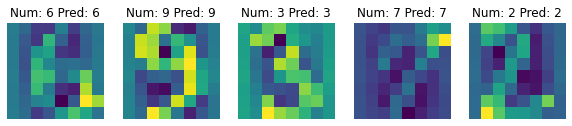

In [16]:
# Display digits and predictions
_, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 3))
for ax, image, label, prediction in zip(axes, X_test, y_test, predictions):
  ax.set_axis_off()
  image = image.reshape(8, 8)
  ax.imshow(image)
  ax.set_title(f"Num: {label} Pred: {prediction}")
plt.show()